In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [1]:
def normalize_data(data):
    """
    normalize_data() : Scales each feature column to 0-1.

    Parameters:
        data : pd.DataFrame, features

    Returns:
        normalized_data : pd.DataFrame, normalized features
    """

    norm_data = data.copy()

    # for each feature, normalize the data
    for feature in norm_data.columns:
        # find min and max of current feature
        f_min = norm_data[feature].min()
        f_max = norm_data[feature].max()

        if f_max - f_min > 0:
            norm_data[feature] = (norm_data[feature] - f_min) / (f_max - f_min)
        else:
            norm_data[feature] = 0.0

    return norm_data

def initialize_centroid(data):
    """
    initialize_centroid() : For each feature find out the minimum and maximum values. Then randomly
            select a value for each feature (using uniform distribution) from the min-max range to 
            initialize one complete centroid.

    Parameters:
        data: pd dataframe, dataset of features for analysis

    Returns:
        centroid: center for given data
    """

    # num of columns in data is the num of features
    num_features = data.shape[1]
    # make empty array
    centroid = np.zeros(num_features)

    # Initialize random value for each dimension (feature)
    for i in range(num_features):
        f_min = data.iloc[:, i].min()
        f_max = data.iloc[:, i].max()
        centroid[i] = np.random.uniform(f_min, f_max)

    # return centroid
    return centroid


def assign_opt_clusters(data, k, opt_centroids, max_iters=200, epsilon=1e-6):
    """
    assign_opt_clusters() : Calculates the best centroids for a given set of data and given 
                        k value

    Parameters:
        data: pd dataframe, dataset of features for analysis
        k: int, number of clusters
        centroids: list, centers for clusters
        max_iters: maximum iterations for finding opt centers
        epsilon: target error/difference between iterations

    Returns:
        centroids: optimal centers per cluster
        centroid_labels: best center for each data point
    """

    X = data.values
    centroids = np.array(opt_centroids)

    # assign each point to a cluster
    for _ in range(max_iters):
        centroid_labels = np.zeros(len(X))

        # assign points to centroids
        for i in range(len(X)):
            dists = []
            for j in range(k):
                # calculate euclidean dist to every cluster
                d = np.sqrt(np.sum((X[i] - centroids[j]) ** 2))
                dists.append(d)
            
            # take min dist location as cluster assignment
            centroid_labels[i] = np.argmin(dists)
        
        # update centers, and initialize using current center shape
        new_centroids = np.zeros_like(centroids)

        # Re-compute centroids
        for j in range(k):
            # pull out each point that matches the label for the current cluster j
            cluster_points = X[centroid_labels == j]

            if len(cluster_points) > 0:
                # get a mean for each feature
                new_centroids[j] = np.mean(cluster_points, axis=0)
            else:
                # keep old center
                new_centroids[j] = centroids[j]
        
        # Check for convergence
        # linalg.norm calculates euclidean dist
        if np.linalg.norm(new_centroids - centroids) < epsilon:
            break
            
        centroids = new_centroids
    
    return centroids, centroid_labels


def plot_3d(data, labels, centroids, title):
    """
    plot_3d() : Plots clusters and their centers on a 3D plot

    Parameters:
        data: pd dataframe, dataset of features for analysis
        labels: list, cluster labels
        centroids: list, centers for clusters
        title: string, name for plot

    Returns:
        None
    """
    X = data.values
    col_names = data.columns[:3] 

    # setup figure and axis
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # add data to plot
    ax.scatter(X[:,0],X[:,1],X[:,2], c=labels)
    # centroids are blue circles
    ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2],c='blue',marker='o')

    # add labels
    ax.set_xlabel(col_names[0])
    ax.set_ylabel(col_names[1])
    ax.set_zlabel(col_names[2])

    ax.set_title(title)
    plt.show()


def davies_bouldin(data, k, labels, centroids):
    """
    davies_bouldin() : Computes the Davies-Bouldin index

    Parameters:
        data : pd.DataFrame of shape (n_samples, n_features)
        k : number of clusters
        labels : list, cluster labels
        centroids : list, centers for clusters

    Returns:
        DB index : float, lower values indicate better clustering
    """    

    # np array from pd df
    X = data.values
    labels = np.array(labels)
    centroids = np.array(centroids)

    # compute Si: average dist of points in clusters to assigned centroid
    S = np.zeros(k)
    for i in range(k):
        # get points assigned to ith cluster
        cluster_pts = X[labels == i]
        
        if len(cluster_pts) > 0:
            # avg euclidean dist for each row of each centroid
            S[i] = np.mean(np.linalg.norm(cluster_pts - centroids[i], axis=1))  # axis=1 for row comparison
        # empty cluster
        else:
            S[i] = 0.0 
        
    # compute R = (Si + Sj) / dist between centroids
    # R is ratio of sum of centroids avg distances (scatter) to dist between centroids
    # (..dist between internal points compared to each other..?S)
    R = np.zeros(k)
    for i in range(k):
        max_r_ij = 0
        for j in range(k):
            # don't compare the same clusters
            if i != j:
                # euclidean dist between diff centroids
                dist_ij =  np.linalg.norm(centroids[i] - centroids[j])
                if dist_ij > 0:
                    r_ij = (S[i] + S[j]) / dist_ij
                    # large R_ij means high intercluster spread or clusters are too close together
                    # store cluster i is most similar to
                    if r_ij > max_r_ij:
                        max_r_ij = r_ij
            
            R[i] = max_r_ij
                    
    
    # compute mean of max of R for each cluster
    # bigger is worse
    DB_index = np.mean(R)
    
    return DB_index


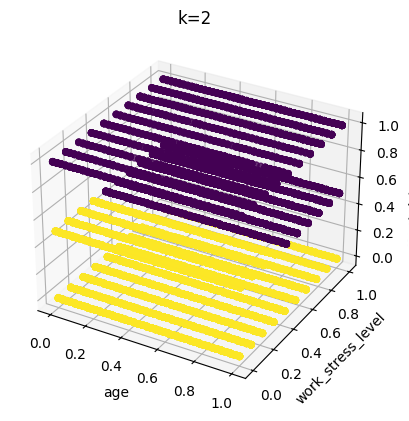

DB Index = 1.465721364292301 for k = 2


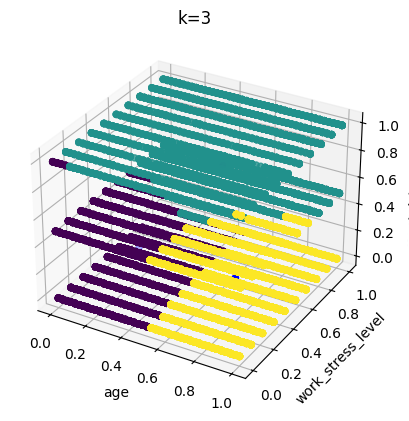

DB Index = 1.3736226137914278 for k = 3


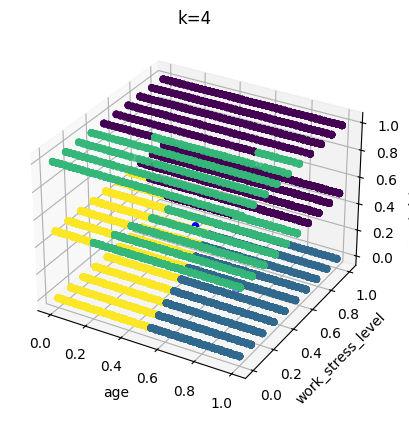

DB Index = 1.2013345071641357 for k = 4


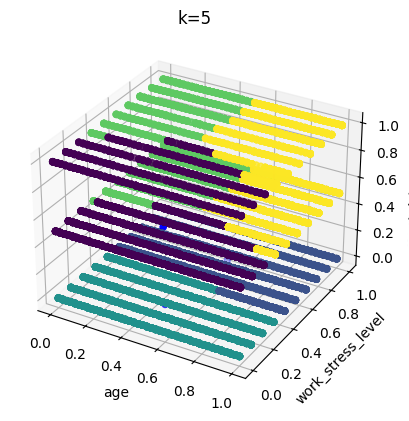

DB Index = 1.1658384140211289 for k = 5


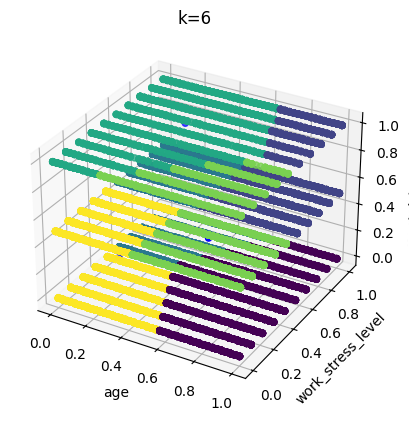

DB Index = 1.037580381944193 for k = 6


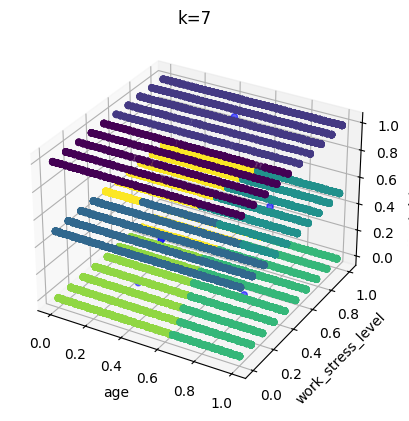

DB Index = 1.0516015564070882 for k = 7


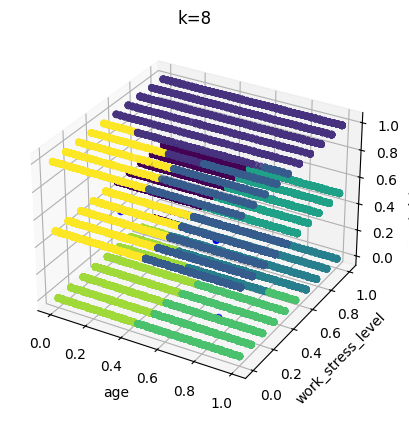

DB Index = 0.9226995544260242 for k = 8


In [6]:
# dataset has converted categorical data to numeric
# gender: male (0), female (1), other (2)
# marital status: single (0), divorced (1), married (2)
# education level: HS (0), bachelor (1), master (2), phd (3)
# employment status: student (0), unemployed (1), employed (2), self-employed (3)
data = pd.read_csv("mental_health_risk_dataset_conv.csv")

#normalize data
norm_data = normalize_data(data)

features = norm_data.iloc[:, [1,10,25]]

for k in range(2,9,1):
        initial_centroids = []
        for _ in range(k):
            initial_centroids.append(initialize_centroid(features))
        
        centroids, labels = assign_opt_clusters(features, k, initial_centroids)
        # plot results
        plot_3d(features, labels, centroids, ("k=" + str(k)))
        
        # calculate DB index
        db_index = davies_bouldin(features,k, labels, centroids)
        print(f"DB Index = {db_index} for k = {k}")